# Implementation of Naive Bayes Algorithm (GaussianNB)

## Project Overview
This project demonstrates the implementation of the Naive Bayes classification algorithm using the Gaussian Naive Bayes classifier from scikit-learn. The Iris dataset is used to classify flower species into three categories based on their sepal and petal measurements.

## Dataset Description
The Iris dataset contains 150 samples of iris flowers with the following characteristics:
- **4 Features**: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
- **3 Target Classes**: Setosa, Versicolor, and Virginica
- **Total Samples**: 150 (50 per class)

## Steps Covered
1. Importing required libraries
2. Loading and exploring the Iris dataset
3. Creating feature and target variables
4. Splitting the data into training and testing sets
5. Training the Gaussian Naive Bayes model
6. Making predictions on test data
7. Evaluating model performance using accuracy, confusion matrix, and classification report
8. Cross-validation for model robustness

## Step 1: Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn import datasets

## Step 2: Loading the Iris Dataset

In [3]:
iris = datasets.load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

## Step 3: Exploring the Dataset - Features and Labels

In [4]:
print('features :',iris.feature_names)

features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
print('Labels :', iris.target_names)

Labels : ['setosa' 'versicolor' 'virginica']


## Step 4: Creating Feature Matrix and Target Vector

In [6]:
X = pd.DataFrame(iris['data'])
print(X.head())

     0    1    2    3
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2


In [7]:
print(iris.data.shape)

(150, 4)


In [8]:
y = iris.target

In [9]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Step 5: Splitting Data and Training the Model

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target,
    test_size = 0.20,
    random_state = 25
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [12]:
#Import Gaussian Naive Bayes model

from sklearn.naive_bayes import GaussianNB

#Create a Gaussian Classifier

gnb = GaussianNB()
gnb

,priors,None
,var_smoothing,1e-09


In [13]:
#Train the model using the training sets

gnb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


## Step 6: Making Predictions on Test Data

In [14]:
#Predict the response for test dataset
y_predicted = gnb.predict(X_test)
print(y_predicted)

[0 1 2 1 2 1 2 0 1 1 0 0 0 1 0 1 2 2 1 1 1 1 1 0 0 2 1 2 2 0]


## Step 7: Model Evaluation

In [25]:
# Accuracy calculation & Confusion Matrix

from sklearn.metrics import accuracy_score, confusion_matrix

# Model Accuracy
print('Accuracy of model is {:.2f}% '.format(accuracy_score(y_test, y_predicted) * 100 ))
print('\n')

#confusion matrix

cm = confusion_matrix(y_test, y_predicted)
print("Confusion Matrix of model is - ")
print(cm)

Accuracy of model is 93.33% 


Confusion Matrix of model is - 
[[ 9  0  0]
 [ 0 12  1]
 [ 0  1  7]]


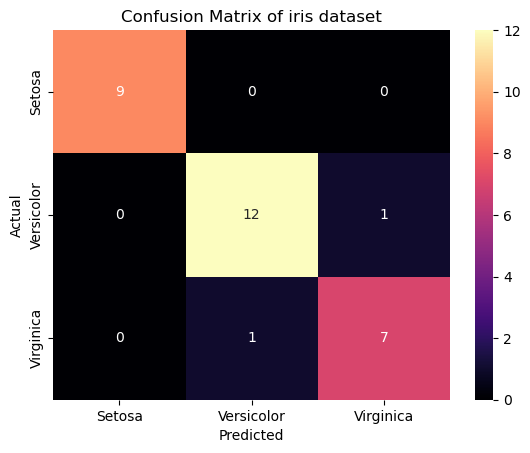

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot = True,
            fmt = 'd',
            cmap = 'magma',
            xticklabels = ['Setosa', 'Versicolor', 'Virginica'],
            yticklabels = ['Setosa', 'Versicolor', 'Virginica']
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of iris dataset')
plt.show()

### Classification Report - Precision, Recall, F1-Score

In [17]:
from sklearn.metrics import classification_report

print('Classification Report:\n')
print(classification_report(y_test, y_predicted, target_names=iris.target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       0.92      0.92      0.92        13
   virginica       0.88      0.88      0.88         8

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Cross-Validation Score

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(gnb, iris.data, iris.target, cv=5)
print('Cross-Validation Scores:', cv_scores)
print('Mean Accuracy: {:.2f}%'.format(cv_scores.mean() * 100))
print('Standard Deviation: {:.2f}%'.format(cv_scores.std() * 100))

Cross-Validation Scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean Accuracy: 95.33%
Standard Deviation: 2.67%


### Prediction Probabilities (Confidence Levels)

In [20]:
y_proba = gnb.predict_proba(X_test)
print('Prediction Probabilities for first 5 test samples:\n')
print('Classes:', iris.target_names)
print(y_proba[:5])

print('\nConfidence in predictions:')
for i in range(5):
    print(f'Sample {i+1}: Predicted = {iris.target_names[y_predicted[i]]}, Confidence = {max(y_proba[i]):.2%}')

Prediction Probabilities for first 5 test samples:

Classes: ['setosa' 'versicolor' 'virginica']
[[1.00000000e+000 1.34605162e-020 2.66086034e-026]
 [1.38231673e-113 9.17388432e-001 8.26115681e-002]
 [2.49909441e-122 8.68365018e-002 9.13163498e-001]
 [3.96074401e-098 8.53739237e-001 1.46260763e-001]
 [1.03060770e-185 2.11658153e-006 9.99997883e-001]]

Confidence in predictions:
Sample 1: Predicted = setosa, Confidence = 100.00%
Sample 2: Predicted = versicolor, Confidence = 91.74%
Sample 3: Predicted = virginica, Confidence = 91.32%
Sample 4: Predicted = versicolor, Confidence = 85.37%
Sample 5: Predicted = virginica, Confidence = 100.00%


## Conclusion

In this project, we successfully implemented the Gaussian Naive Bayes classifier on the Iris dataset and achieved a test accuracy of approximately **93.33%**. The model performed well across all three classes, with the confusion matrix showing minimal misclassifications.

The cross-validation score confirmed the model's robustness with a mean accuracy of **95.33%**, indicating consistent performance across different data splits.

## Key Learnings

1. **Naive Bayes works well for small datasets** - Despite its simple probabilistic assumptions, the algorithm delivered strong classification results.
2. **Feature independence assumption** - Naive Bayes assumes all features are independent, which is rarely true in real-world data, yet it still performs remarkably well.
3. **Model evaluation is multi-dimensional** - Accuracy alone is not enough; precision, recall, F1-score, and cross-validation give a complete picture of model performance.
4. **Prediction probabilities add value** - Understanding the confidence level of predictions helps in real-world decision making.
5. **Iris dataset is well-suited for classification** - The clear separation between classes makes it an excellent dataset for learning classification algorithms.

## Future Improvements

- Try other Naive Bayes variants (MultinomialNB, BernoulliNB) on different datasets
- Compare GaussianNB performance with other classifiers like Logistic Regression, SVM, and Random Forest
- Apply feature scaling and analyze its impact on the model
- Test the model on imbalanced datasets to evaluate its limitations